In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

run = pickle.loads(Path(".run.pkl").read_bytes())
card, ev, constants = run["card"], run["evidence"], run["constants"]
gates = {g["number"]: g for g in run["gates"]}
pd.set_option("display.max_colwidth", None)
plt.rcParams.update({"figure.figsize": (9, 3), "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10})
INK, GREY, MARK = "#1f4e79", "#a6a6a6", "#c0504d"


def text(value):
    return " ".join(str(value).split()) if value else "—"


def shown(value):
    if value is None:
        return "—"
    if isinstance(value, (list, tuple)):
        return "; ".join(map(str, value)) or "none"
    if isinstance(value, float):
        return float(f"{value:.4g}")
    return value


def table(figures):
    display(pd.Series({k: shown(v) for k, v in figures.items()}, dtype=object).to_frame().T.set_index(pd.Index([""])))


def gate(number):
    g = gates[number]
    reason = g["reason"].removeprefix("not computed: ")
    word = {True: "Passes", False: "Fails", None: "Not computed"}[g["passed"]]
    display(Markdown(f"**{word}**: {reason.rstrip('.')}."))
    if g["figures"]:
        table(g["figures"])


failed = run["failed"]
headline = ("passes gates 1 to 7" if failed is None
            else f"stops at gate {failed}, {gates[failed]['name'].lower()}: {gates[failed]['reason']}")
display(Markdown(f"# {card['id']}\n\nTheory **{card.get('theory', '—')}**. The battery's verdict: "
                 f"the strategy {headline}."))

# SC-023-01-same-month-across-assets

Theory **SC-023**. The battery's verdict: the strategy stops at gate 2, economic edge: Sharpe 0.385 below 0.4; Sharpe 0.385 against the benchmark's 0.674, alpha -0.99%; at twice the costs, Sharpe 0.325 and alpha -2.02%.

## Thesis

In [2]:
prediction = card.get("prediction") or {}
if isinstance(prediction, dict):
    prediction = ", ".join(f"{k}: {v}" for k, v in prediction.items())
display(Markdown(f"**Mechanism.** {text(card.get('mechanism'))}\n\n"
                 f"**Prediction.** {text(prediction)}\n\n"
                 f"**What would refute it.** {text(card.get('refuted_if'))}\n\n"
                 f"**Horizon.** {text(card.get('horizon'))}"))

**Mechanism.** Assets carry a recurring calendar signature of their own: recurring cycles of demand, risk, investor clienteles, sentiment or constraints return at the same time each year, so that an asset that did well relative to others in a calendar month in past years, beyond what its exposure to the market's month gave it, tends to do so in that month again, across asset classes and indices as in stocks.

**Prediction.** sign: positive, size: a judgment, from the sources -- each month, the equal-weighted residual return, beyond each asset's beta to the universe's average, of the two assets ranked highest on their past residual returns in that calendar month about 0 to +0.25% a month above the equal-weighted residual of all the assets ranked, from February 2010 to December 2022; the rule's alpha over the assets held always in equal parts about 0 to +3% a year before costs of about 1.0 to 1.2% a year, an appraisal ratio of about -0.12 to +0.18 after costs; the base expected to fail gate 2 or gate 3, gate 4 and gate 5, and perhaps gate 6 on one asset's share of the profit if the ranking keeps returning to a few volatile assets

**What would refute it.** Judged before costs: over the in-sample calendar months from February 2010 to December 2022, each ranked asset's return in the month, compounded from the daily returns of the market's sessions in it, less its beta, estimated before the month as in the signal, times the average's return that month; the equal-weighted residual of the top assets the base ranks highest for the month, less the equal-weighted residual of all the assets it ranks; the mean of that difference over the months, its standard error, the standard deviation of the monthly differences over the square root of their number, and its t statistic, computed apart from the battery; returns, betas and residuals are raw, not less the bill. The theory is refuted in this form if that t statistic is -0.35 or below. Above it, short of passing gates 1 to 7, it is not proven, not refuted; a base that passes gates 1 to 7 while the clause refutes leaves the theory refuted in this form. Of SC-023's refutation criteria the first is graded at the monthly frequency on each asset's calendar beyond its beta, the weekday frequency being out of reach; the second and third are reported. Reported, not graded: the same gap with the assets ranked on their raw past returns in the same month and graded on raw returns; each month's rank correlation between the signal and the month's residuals across the ranked assets, its mean and t statistic, and the same for the raw ranking; the two assets ranked lowest less the average; the same gap with the signal read on the last year alone; the same gap with the signal less the asset's mean residual over all the window's months; the same gap with the assets ranked on their residual return over the twelve months before the month, and the rank correlation of that ranking with the signal; for each month's top group, its average residual over the other eleven months of the same year less the ranked assets' average over them, and its beta to the average in the matching month against its beta in the other months; the rule's average weights held fixed over the period, against the rule; the gap within the sector funds alone and across the other assets alone; over 2010-2016, 2017-2022 and without 2020; how often each asset was held, the months a Treasury fund was, and each asset's share of the profit; the base's alpha before and after costs, and the neighbours' and the one-day-late rule's alphas and appraisal ratios.

**Horizon.** months

## Data

In [3]:
x = ev.get("excess")
start, end = constants["in sample"]
cannot_run = gates[1]["reason"].startswith("the strategy cannot run")
broke = gates[1]["reason"].startswith("cannot be computed: ")        # the runs every gate judges broke
evaluated = (f"evaluated from the first session the strategy holds an asset, {x.index[0].date()}, to "
             f"{x.index[-1].date()}" if x is not None and len(x)
             else "not evaluated: the strategy cannot run" if cannot_run
             else f"not evaluated: the runs every gate judges broke ({gates[1]['reason'].split(': ', 1)[1]})"
             if broke else "not evaluated: nothing was held")
display(Markdown(
    f"Daily closes adjusted for dividends and splits, snapshot **{run['snapshot']}**. "
    f"Universe: {', '.join(card['universe'])}. In-sample {start} to {end}, {evaluated}; "
    f"holdout {' to '.join(constants['holdout'])}, opened once, at gate 7. "
    f"Returns are above the Treasury-bill rate, net of costs."))

Daily closes adjusted for dividends and splits, snapshot **2026-09-22+2026-09-23**. Universe: XLB, XLC, XLE, XLF, XLI, XLK, XLP, XLRE, XLU, XLV, XLY, SPY, QQQ, IWM, EFA, EEM, GLD, SLV, DBC, IEF, TLT. In-sample 2005-01-01 to 2022-12-31, evaluated from the first session the strategy holds an asset, 2010-02-01, to 2022-12-30; holdout 2023-01-01 to 2025-12-31, opened once, at gate 7. Returns are above the Treasury-bill rate, net of costs.

## Signal

Sessions are placed on the New York Stock Exchange's calendar of scheduled sessions, derived from its holiday rules alone and read from no price: weekdays less New Year's Day (on 2 January when 1 January is a Sunday, not observed when it is a Saturday), Martin Luther King Jr. Day, Washington's Birthday, Good Friday, Memorial Day, Juneteenth from 2022, Independence Day, Labor Day, Thanksgiving and Christmas, with Juneteenth, Independence Day and Christmas moved to the Friday before when they fall on a Saturday and to the Monday after when on a Sunday. An asset's return in a calendar month is its return from its last close before the month to its last close in it, on the market's closes, raw, not less the bill; the average's return in a month is the equal-weighted return of the universe's assets that have a return in it. On each session of the market whose next scheduled session falls in a new calendar month m, reading the closes up to the session before, the window is the calendar months from 12 times `years` months before month m to the month before the month in progress, which is left out, its return ending at the session's own close: 59 months for the base. An asset is ranked when it trades and its returns in every month of the window are known: its beta is the slope of its monthly returns on the average's over the window, by ordinary least squares with an intercept; its residual in a month of the window is its return less its beta times the average's; its signal is the mean of its residuals in the window's months m. The target is the `top` assets ranked highest on the signal, in equal parts, or all those ranked when fewer; no asset ranked, nothing. No target is set on the other sessions.

- **years**: the previous years of the same calendar month averaged, and of the beta's window
- **top**: how many of the assets ranked highest are held

,years,top
base,5,2


Parameter neighbours, moved one at a time for gate 6: years at ±25%: 4, 6; years at ±50%: 2, 8; top at ±25%: 1, 3; top at ±50%: 1, 3.

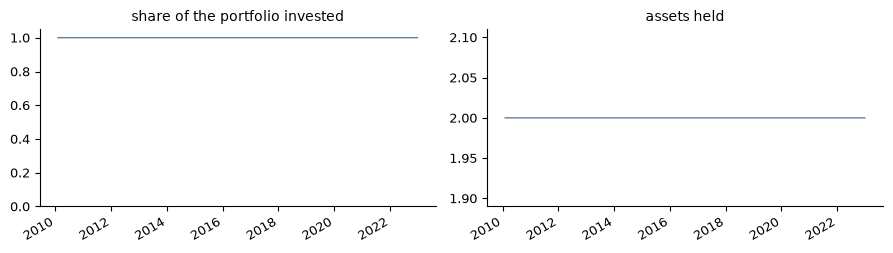

In [4]:
display(Markdown(text(card.get("signal"))))
parameters = card.get("parameters") or {}
if parameters:
    display(Markdown("\n".join(f"- **{k}**: {text(v)}" for k, v in parameters.items())))
variants = pd.DataFrame(card["variants"], index=["base"] + [f"variant {k}" for k in range(1, len(card["variants"]))])
display(variants)
neighbours = card.get("neighbours") or {}
if neighbours:
    display(Markdown("Parameter neighbours, moved one at a time for gate 6: "
                     + "; ".join(f"{p} at ±{step}%: {', '.join(map(str, values))}"
                                 for p, steps in neighbours.items() for step, values in steps.items()) + "."))
if "exposure" in ev:
    fig, (a, b) = plt.subplots(1, 2, figsize=(9, 2.6))
    ev["exposure"].plot(ax=a, color=INK, linewidth=0.7)
    a.set_title("share of the portfolio invested")
    a.set_ylim(0, 1.05)
    ev["assets held"].plot(ax=b, color=INK, linewidth=0.7)
    b.set_title("assets held")
    for axis in (a, b):
        axis.set_xlabel("")
    plt.tight_layout()

## Equity against the benchmark

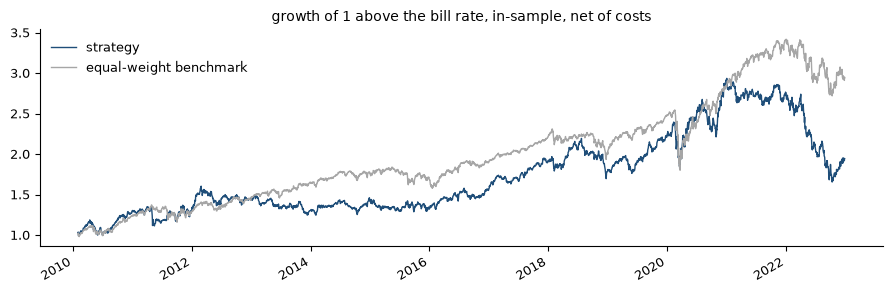

In [5]:
if x is not None and len(x):
    b = ev["benchmark excess"]
    fig, ax = plt.subplots()
    (1 + x).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + b).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title("growth of 1 above the bill rate, in-sample, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
else:
    display(Markdown("The strategy cannot run: there is no equity to draw." if cannot_run
                     else "The runs every gate judges broke: there is no equity to draw." if broke
                     else "Nothing was held in-sample: there is no equity to draw."))

## Gate 1 · Hygiene

Protects against look-ahead, bad data and too little evidence.

**Passes**: no look-ahead on 100 dates, 154 decisions over 12.9 years.

,dates checked,look-ahead breaks,same-day breaks,memory,memory dates checked,memory breaks,data problems,clustered decisions,years in-sample,years needed
,100,0,0,1290,50,0,none,154,12.91,5


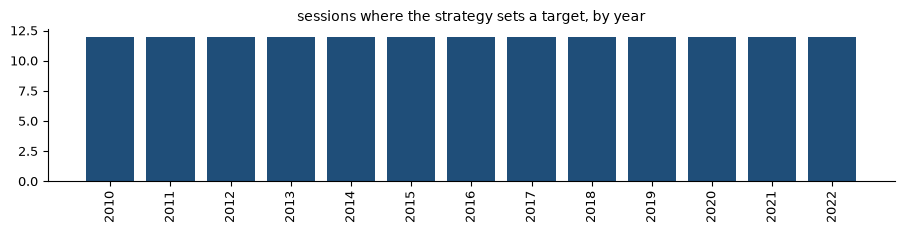

In [6]:
gate(1)
days = ev.get("target days")
if days is not None and len(days):
    per_year = pd.Series(1, index=days).groupby(days.year).sum()
    fig, ax = plt.subplots(figsize=(9, 2.4))
    ax.bar(per_year.index.astype(str), per_year, color=INK)
    breaks = sorted({d.year for variant in ev["timing breaks"].values() for kind in variant.values() for d in kind})
    for year in breaks:
        ax.bar(str(year), per_year.get(year, 0), color=MARK)
    ax.set_title("sessions where the strategy sets a target, by year" + ("; red: a timing break" if breaks else ""))
    ax.tick_params(axis="x", rotation=90)
    plt.tight_layout()

## Gate 2 · Economic edge

Protects against an edge explained by costs or by market exposure.

**Fails**: Sharpe 0.385 below 0.4; Sharpe 0.385 against the benchmark's 0.674, alpha -0.99%; at twice the costs, Sharpe 0.325 and alpha -2.02%.

,Sharpe,benchmark Sharpe,alpha,Sharpe at 2x costs,alpha at 2x costs,gross Sharpe,costs a year,costs in Sharpe units
,0.3854,0.6739,-0.009893,0.325,-0.02016,0.4457,0.01034,0.06012


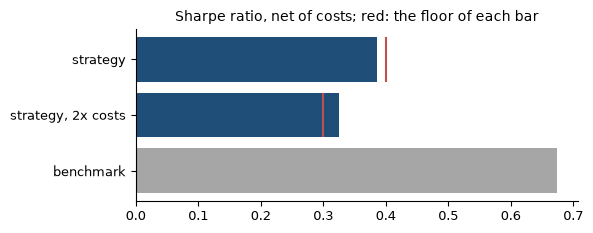

In [7]:
gate(2)
f = gates[2]["figures"]
if f:
    floors = constants["floors"]
    rows = [("benchmark", f["benchmark Sharpe"], GREY, None),
            ("strategy, 2x costs", f["Sharpe at 2x costs"], INK, floors["Sharpe at 2x costs"]),
            ("strategy", f["Sharpe"], INK, floors["Sharpe"])]
    fig, ax = plt.subplots(figsize=(6, 2.4))
    for y, (label, value, colour, floor) in enumerate(rows):
        ax.barh(y, value, color=colour)
        if floor is not None:
            ax.vlines(floor, y - 0.4, y + 0.4, color=MARK, linewidth=1.5)
    ax.set_yticks(range(len(rows)), [r[0] for r in rows])
    ax.set_title("Sharpe ratio, net of costs; red: the floor of each bar")
    plt.tight_layout()

## Gate 3 · Significance

Protects against luck, and against being paid only for being invested. A strategy that holds nearly every asset that trades is close to its benchmark: its placebos differ from it by little, details of the path decide its rank, and gates 2 and 4 judge it.

**Fails**: PSR 0.930 below 0.95; beats 42.9% of its shifted placebos, fewer than 90%.

,PSR,placebo sessions,placebos,placebos beaten
,0.93,3254,1000,0.429


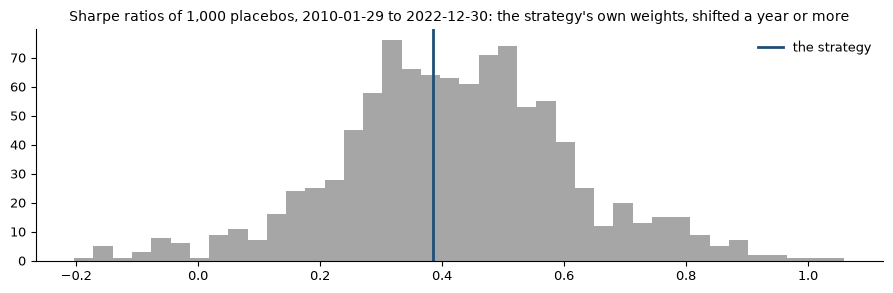

In [8]:
gate(3)
if "placebos" in ev:
    fig, ax = plt.subplots()
    ax.hist(ev["placebos"], bins=40, color=GREY)
    ax.axvline(ev["placebo own Sharpe"], color=INK, linewidth=2, label="the strategy")
    first, last = (d.date() for d in ev["placebo window"])
    ax.set_title(f"Sharpe ratios of {len(ev['placebos']):,} placebos, {first} to {last}: the strategy's own weights, "
                 f"shifted a year or more")
    ax.legend(frameon=False)
    plt.tight_layout()
    if ev.get("placebo late assets"):
        display(Markdown(f"Assets that start trading after {first}: {', '.join(ev['placebo late assets'])}. A placebo "
                         f"shifts their weights only between days when they trade. Where it draws from a day before their "
                         f"start, it keeps their own weights; where it draws from a day after their start onto a day before "
                         f"it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its "
                         f"timing: skill that lies before a late start is judged against placebos that share it, and is "
                         f"found less often. Where the strategy holds none of the assets shifted that day, the shifted "
                         f"weights take that share instead."))

## Gate 4 · Multiple testing

Protects against the best of many tries: the edge, hedged of the benchmark, deflated by every trial the registry holds.

**Fails**: DSR 0.005 below 0.9 over 49 effective trials.

,trials,effective trials,appraisal ratio,Sharpe expected by luck,DSR
,52,49,-0.07629,0.6447,0.004816


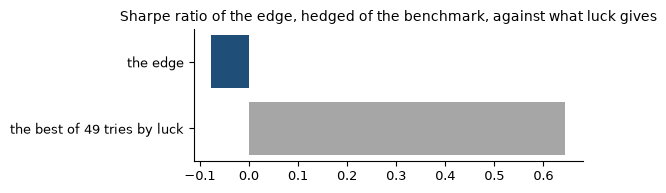

In [9]:
gate(4)
f = gates[4]["figures"]
if f and "appraisal ratio" in f:
    fig, ax = plt.subplots(figsize=(6, 2.0))
    ax.barh([0, 1], [f["Sharpe expected by luck"], f["appraisal ratio"]], color=[GREY, INK])
    tries = f["effective trials"]
    ax.set_yticks([0, 1], [f"the best of {tries} {'try' if tries == 1 else 'tries'} by luck", "the edge"])
    ax.set_title("Sharpe ratio of the edge, hedged of the benchmark, against what luck gives")
    plt.tight_layout()

## Gate 5 · Stability

Protects against an edge that lives in one variant or one episode.

**Fails**: the blend of the variants fails gates 2, 3 and 4; alpha positive in 1 of 5 blocks, fewer than 3; alpha -2.92% without its best year, 2020.

,blend passes gate 2,blend passes gate 3,blend passes gate 4,worst variant Sharpe,positive blocks,best year,alpha without the best year
,False,False,False,0.3854,1,2020,-0.02921


The blend of the variants: gate 2, Sharpe 0.385 below 0.4; Sharpe 0.385 against the benchmark's 0.674, alpha -0.99%; at twice the costs, Sharpe 0.325 and alpha -2.02%; gate 3, PSR 0.930 below 0.95; beats 41.2% of its shifted placebos, fewer than 90%; gate 4, DSR 0.005 below 0.9 over 49 effective trials.

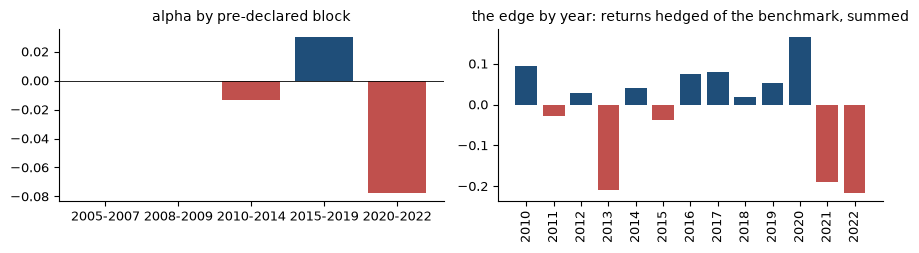

In [10]:
gate(5)
if "blocks" in ev:
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    blocks = pd.Series({k: (v if v is not None else np.nan) for k, v in ev["blocks"].items()})
    a.bar(blocks.index, blocks.fillna(0), color=[INK if v > 0 else MARK for v in blocks.fillna(0)])
    a.set_title("alpha by pre-declared block")
    a.axhline(0, color="black", linewidth=0.6)
    by_year = ev["edge by year"]
    c.bar(by_year.index.astype(str), by_year, color=[INK if v > 0 else MARK for v in by_year])
    c.set_title("the edge by year: returns hedged of the benchmark, summed")
    c.tick_params(axis="x", rotation=90)
    plt.tight_layout()
failed_blend = {n: reason for n, reason in ev.get("blend", {}).items() if gates[5]["figures"].get(f"blend passes gate {n}") is False}
if failed_blend:
    display(Markdown("The blend of the variants: " + "; ".join(f"gate {n}, {r}" for n, r in failed_blend.items()) + "."))

## Gate 6 · Robustness

Protects against a peak, one asset, timing too tight and a clone.

**Fails**: a ±25% neighbour keeps -4%, below 50%.

,neighbour median ratio,lowest ±25% ratio,neighbours that hold the base,worst cluster out,worst cluster out ratio,largest P&L share,asset with the largest share,one day late ratio,highest correlation with a survivor,survivor most correlated
,1.166,-0.0379,none,bonds,0.7907,0.2403,IWM,0.843,—,—


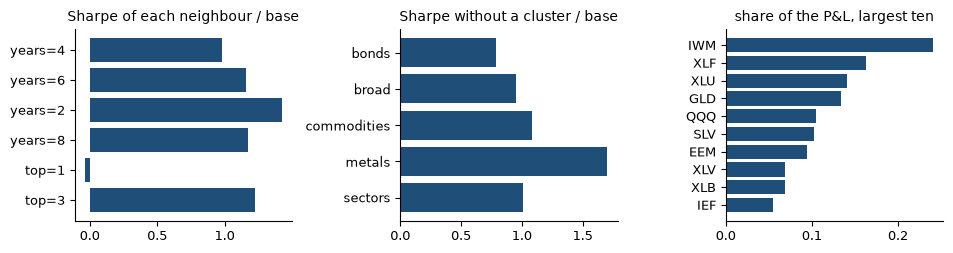

In [11]:
gate(6)
panels = [(k, ev.get(k)) for k in ("neighbours", "clusters out", "P&L shares") if ev.get(k) is not None and len(ev.get(k))]
if panels:
    fig, axes = plt.subplots(1, len(panels), figsize=(3.2 * len(panels), 2.6))
    for axis, (name, values) in zip(np.atleast_1d(axes), panels):
        values = pd.Series(values).head(10)
        axis.barh(values.index.astype(str), values, color=INK)
        axis.set_title({"neighbours": "Sharpe of each neighbour / base", "clusters out": "Sharpe without a cluster / base",
                        "P&L shares": "share of the P&L, largest ten"}[name])
        axis.invert_yaxis()
    plt.tight_layout()
if ev.get("without bitcoin"):
    display(Markdown("Without bitcoin, gate 2's figures:"))
    table(ev["without bitcoin"])

## Gate 7 · Sealed holdout

Protects against bugs and large decay, on years kept aside and opened once.

**Passes**: holdout Sharpe 0.99 and alpha 6.03%, both above the in-sample 10th percentile.

,holdout Sharpe,Sharpe floor,holdout alpha,alpha floor,variants rewritten,dates checked,look-ahead breaks,same-day breaks,data problems
,0.9898,-0.3795,0.06025,-0.1245,0,20,0,0,none


Red: the 10th percentile of the in-sample paths, the floor; blue: the holdout.

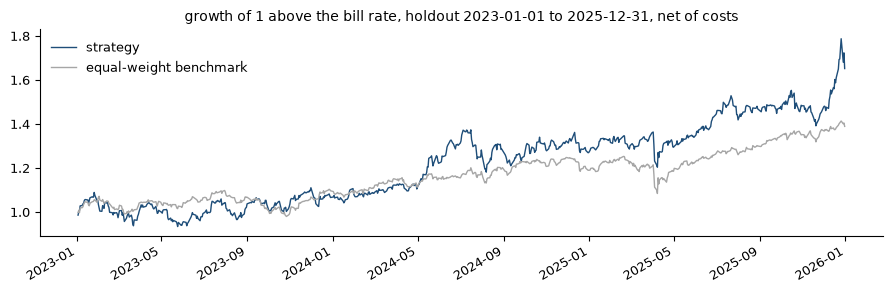

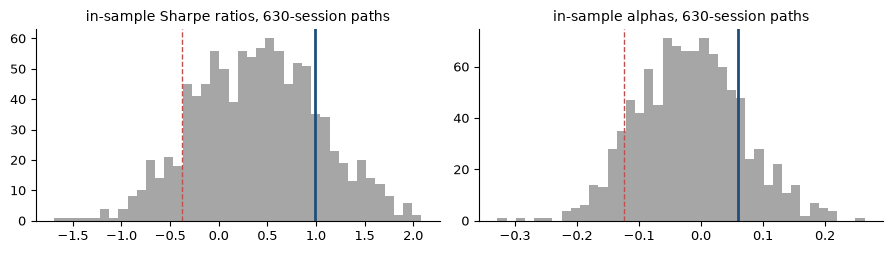

In [12]:
gate(7)
f = gates[7]["figures"]
if "holdout excess" in ev and len(ev["holdout excess"]):
    fig, ax = plt.subplots()
    (1 + ev["holdout excess"]).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + ev["holdout benchmark excess"]).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title(f"growth of 1 above the bill rate, holdout {' to '.join(constants['holdout'])}, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
if "bootstrap" in ev and f:
    pct = constants["percentile"]
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    for axis, key, mark, label in ((a, "Sharpe", "holdout Sharpe", "Sharpe ratio"), (c, "alpha", "holdout alpha", "alpha")):
        axis.hist(ev["bootstrap"][key], bins=40, color=GREY)
        axis.axvline(np.percentile(ev["bootstrap"][key], pct), color=MARK, linestyle="--", linewidth=1)
        axis.axvline(f[mark], color=INK, linewidth=2)
        axis.set_title(f"in-sample {label}s, {constants['window']}-session paths")
    plt.tight_layout()
    display(Markdown(f"Red: the {pct}th percentile of the in-sample paths, the floor; blue: the holdout."))

## Verdict

In [13]:
table = pd.DataFrame([{"gate": f"{g['number']} · {g['name']}",
                       "result": {True: "passes", False: "fails", None: "not computed"}[g["passed"]],
                       "reason": g["reason"].removeprefix("not computed: ")} for g in run["gates"]]).set_index("gate")
display(table)
display(Markdown(f"Thresholds, version {run['thresholds']}. What the verdict means for the theory, and what was "
                 f"learned, is written in [verdict.md](verdict.md)."))

,result,reason
gate,,
1 · Hygiene,passes,"no look-ahead on 100 dates, 154 decisions over 12.9 years"
2 · Economic edge,fails,"Sharpe 0.385 below 0.4; Sharpe 0.385 against the benchmark's 0.674, alpha -0.99%; at twice the costs, Sharpe 0.325 and alpha -2.02%"
3 · Significance,fails,"PSR 0.930 below 0.95; beats 42.9% of its shifted placebos, fewer than 90%"
4 · Multiple testing,fails,DSR 0.005 below 0.9 over 49 effective trials
5 · Stability,fails,"the blend of the variants fails gates 2, 3 and 4; alpha positive in 1 of 5 blocks, fewer than 3; alpha -2.92% without its best year, 2020"
6 · Robustness,fails,"a ±25% neighbour keeps -4%, below 50%"
7 · Sealed holdout,passes,"holdout Sharpe 0.99 and alpha 6.03%, both above the in-sample 10th percentile"


Thresholds, version 4. What the verdict means for the theory, and what was learned, is written in [verdict.md](verdict.md).